**🌐 언어:** [← English](/regression/05-the-unreasonable-effectiveness-of-linear-regression-minimal) | **한국어**

# 선형회귀의 놀라운 효과 (간단 버전)

처치가 무작위로 배정되면, 선형회귀는 RCT나 A/B 테스트에서 집단 평균 차이와 같은 아이디어를 매우 효율적으로 복원하는 방법입니다. 무작위가 아닌 데이터에서는 더 주의해야 합니다. 먼저 변수들이 어떻게 연결되어 있는지 살펴보고, 어떤 중요한 변수가 빠졌을 수 있는지 물어야 합니다. 누락변수편향(OVB)이 남아 있을 수 있기 때문입니다.


In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")


## 데이터 불러오기

`wage.csv`만 사용합니다.


In [2]:
wage = pd.read_csv("data/wage.csv").dropna().copy()
wage["hwage"] = wage["wage"] / wage["hours"]

wage[["wage", "hours", "hwage", "lhwage", "educ", "IQ", "exper", "tenure", "age"]].head()


,wage,hours,hwage,lhwage,educ,IQ,exper,tenure,age
0,769,40,19.225,2.956212,12,93,11,2,31
2,825,40,20.625,3.026504,14,108,11,9,33
3,650,40,16.250,2.788093,12,96,13,7,32
4,562,40,14.050,2.642622,11,74,14,5,34
6,600,40,15.000,2.708050,10,91,13,0,30


## 먼저 관계를 확인하기

관찰자료에서 회귀를 인과적으로 해석하기 전에, 교육, 임금, 능력 대리변수, 배경 변수들이 함께 어떻게 움직이는지 살펴보는 것이 도움이 됩니다.


In [3]:
key_vars = ["lhwage", "educ", "IQ", "exper", "tenure", "age", "meduc", "feduc"]
wage[key_vars].corr().round(2)


,lhwage,educ,IQ,exper,tenure,age,meduc,feduc
lhwage,1.00,0.27,0.27,0.06,0.17,0.18,0.20,0.20
educ,0.27,1.00,0.54,-0.45,-0.03,0.05,0.36,0.42
IQ,0.27,0.54,1.00,-0.23,0.02,-0.02,0.32,0.34
exper,0.06,-0.45,-0.23,1.00,0.29,0.47,-0.16,-0.25
tenure,0.17,-0.03,0.02,0.29,1.00,0.28,0.01,-0.04
age,0.18,0.05,-0.02,0.47,0.28,1.00,0.01,-0.06
meduc,0.20,0.36,0.32,-0.16,0.01,0.01,1.00,0.58
feduc,0.20,0.42,0.34,-0.25,-0.04,-0.06,0.58,1.00


## 분석

단순 회귀부터 시작한 뒤, 그럴듯한 통제변수를 추가합니다. 두 결과의 차이는 관찰자료 추정치가 무엇을 통제하느냐에 의존한다는 실용적인 경고입니다.


In [4]:
simple_model = smf.ols("lhwage ~ educ", data=wage).fit()

controls = [
    "IQ", "exper", "tenure", "age", "married", "black",
    "south", "urban", "sibs", "brthord", "meduc", "feduc"
]
controlled_model = smf.ols(
    "lhwage ~ educ + " + " + ".join(controls),
    data=wage,
).fit()

pd.DataFrame(
    {
        "educ_계수": [simple_model.params["educ"], controlled_model.params["educ"]],
        "p값": [simple_model.pvalues["educ"], controlled_model.pvalues["educ"]],
        "신뢰구간_하한": [simple_model.conf_int().loc["educ", 0], controlled_model.conf_int().loc["educ", 0]],
        "신뢰구간_상한": [simple_model.conf_int().loc["educ", 1], controlled_model.conf_int().loc["educ", 1]],
    },
    index=["단순 모형", "통제 포함"],
).round(4)


,educ_계수,p값,신뢰구간_하한,신뢰구간_상한
단순 모형,0.0536,0.0000,0.0388,0.0684
통제 포함,0.0411,0.0001,0.0213,0.0610


/Users/edgar/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/edgar/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/edgar/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/edgar/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/edgar/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: Use

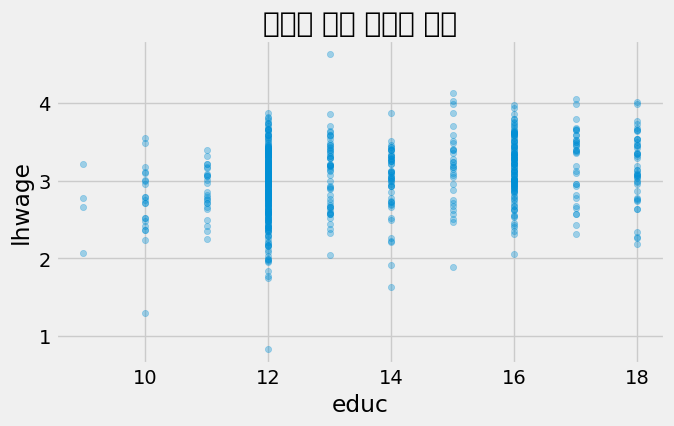

In [5]:
ax = wage.plot.scatter(x="educ", y="lhwage", alpha=0.35, figsize=(7, 4))
ax.set_title("교육과 로그 시간당 임금")
plt.show()


## 결과

무작위 배정 환경에서 회귀는 종종 집단 평균 차이와 같은 처치 대비를 더 간결하게 추정하는 방법일 뿐입니다. 하지만 여기의 임금 데이터는 관찰자료이므로, `educ`의 회귀계수는 더 취약합니다.

통제변수를 추가하면 추정치가 바뀌는데, 이는 다른 변수들과의 관계가 중요하다는 신호입니다. 그렇더라도 이 결과가 자동으로 인과적이 되는 것은 아닙니다. 가족의 부, 야망, 다른 능력 지표처럼 관측되지 않은 요인들이 여전히 누락변수편향을 만들 수 있기 때문입니다.
